In [1]:
# 라이브러리 불러오기
import selenium.webdriver as wb
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from nltk.util import ngrams
import time
from tqdm import tqdm
import pandas as pd
import re # 정규표현식
from kiwipiepy import Kiwi # 키위 형태소 분석기
from wordcloud import WordCloud # 워드클라우드 생성 도구
from collections import Counter # 단어가 나온 횟수를 세주는 도구
import matplotlib.pyplot as plt #t시각화도구
from PIL import Image
import numpy as np

# 문자열 전처리 함수 -> 숫자, 문자, (?.!,¿) 제외하고 공백으로 대체
def preprocess_sentence_kr(w):
  w = w.strip()
  w = re.sub(r"[^0-9가-힣?.!,¿]+", " ", w) 
  w = w.strip() 
  return w

def make_bi_token(tokens):
    bi_tokens = list(ngrams(tokens,2))
    return tokens + [' '.join(bi) for bi in bi_tokens]

stopwords = set([
    '때', '집', '방', '말'
])

In [2]:
options = Options()

# 1. 봇 감지 방지를 위한 유저 에이전트 설정
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36")

# 2. 웹드라이버 인식 방지 설정
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option('useAutomationExtension', False)

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

# 3. 브라우저 내부의 'webdriver' 속성을 제거하는 스크립트 실행
driver.execute_cdp_cmd("Page.addScriptToEvaluateOnNewDocument", {
    "source": """
        Object.defineProperty(navigator, 'webdriver', {
            get: () => undefined
        })
    """
})

{'identifier': '2'}

In [1]:
driver.get('https://ohou.se/')
driver.find_element(By.CSS_SELECTOR,'input.css-pxfbsp.e1rynmtb2').send_keys('혼수'+'\n')

NameError: name 'driver' is not defined

In [4]:
tab = driver.find_elements(By.CSS_SELECTOR, 'div.css-yc5pvq')
tab[4].click() #커뮤니티 클릭

In [5]:
href_list=[]
for i in range(10):
    body = driver.find_element(By.TAG_NAME,'body')
    body.send_keys(Keys.END)
    time.sleep(1)
    link = driver.find_elements(By.CSS_SELECTOR,'div.css-1161qt5>article>a')
    for i in range(len(link)):
        href_list.append(link[i].get_attribute('href'))

In [6]:
driver.get(href_list[0])
time.sleep(2)

In [7]:
result = driver.find_elements(By.CSS_SELECTOR,'div.css-12595yo')
result[0].text

"숙면이 제일 중요하다는 생각에 큰맘 먹고 트윈 침대를 선택했어요. 각자 편하게 자는 건 좋은데, 문제는 안방이 침대만으로 꽉 차버렸다는 거예요! \n\n분명 머릿속으로는 예쁜 협탁도 놓고 조명도 근사하게 배치하는 그림을 그렸거든요. 하지만 현실은 침대 두 개가 방을 점령하는 바람에 다른 가구는 놓을 엄두도 못 내고 있어요.\n\n수면의 질은 챙겼지만, 안방에서 누릴 수 있는 '공간의 여유'는 통째로 반납한 기분입니다. 트윈 침대를 고민하신다면 침대 크기만 보지 마시고, 방 전체 면적과 남는 공간을 꼭 계산해 보세요. 안방이 잠만 자는 감옥이 될 수도 있으니까요!\n\n#혼수실패기"

In [8]:
f = open('./data/오늘의집 혼수.txt','w')

# 링크 반복
for i in tqdm(range(len(href_list))):
    driver.get(href_list[i])
    time.sleep(2)


    result = driver.find_elements(By.CSS_SELECTOR,'div.css-12595yo')
    for j in range(len(result)):
        content = preprocess_sentence_kr(result[j].text)
        f.write(content)

f.close()

100%|██████████| 94/94 [04:19<00:00,  2.76s/it]


In [9]:
preprocess_sentence_kr(result[0].text)

'34평 아파트 현재 6인용 사각 식탁 사용중인데 혼수로 제가 고른거긴하지만 스틸다리도 의자도 너무 어둡고 딱딱해서 분위기를 바꾸고싶어졌어요'

In [28]:
# 텍스트 파일 열기
f = open('./data/오늘의집 혼수.txt','r')
text = f.readline()
f.close()
text

'사실 예뻐서 실패 아이템이라 밀어붙이기는 좀 그렇지만요.. 문을 열고 닫는 방식이 그렇게 예쁘지 ?! 않아요. 앞으로 당기면서 접혀지는 슬라이드식이거든요, 이사를 거치면서 원 상태보다 낡아지는 것도 그렇고 이제 아이가 있으니 늘어나는 옷과 정리를 위해 방 하나에 깔끔하고 수납력 좋은 한샘 행거를 설치했어요. 드레스룸으로 사용하는 공간이 생겨버리니 이 예쁜.. 실용성 떨어지는 옷장은 처치곤란이 되었버렸네요, 아쉽지만 첫 신혼집에서 함께 했던 이 옷장은 서서히 처분할 계획에 있답니다 모두들 실용적이고 예쁜 드레스룸을 만들기를 바랍니다! 혼수실패기 콘수프기록집 기록챌린지혼수 가구, 가전 준비하면서 정말 많이 비교하고 따져봤어요. 디자인, 기능, 가격까지 하나하나 고민해서 선택했고 대부분은 지금도 너무 만족하면서 잘 쓰고 있는데요. 딱 한 가지, 고를 때부터 계획대로 되지 않아서 아직도 아쉬움이 남는 가전이 있어요. 바로 노크온 냉장고입니다.노크온 냉장고는 말 그대로 냉장고 한 면을 두드리면 내부 조명이 켜지면서 문을 열지 않고도 안을 볼 수 있는 기능이에요. 광고에서는 참 편리해 보이죠. 사실 저는 이 기능이 필요 없다고 생각해서 처음부터 노크온 없는 모델로 마음을 정해두고 갔어요. 그런데 제가 가전을 구매했던 백화점 매장에서는 당시 노크온이 없는 모델은 선택지가 거의 없더라고요. 결국 노크온 모델로 가게 되었고, 대신 키친핏 가격에 맞춰 추가 할인을 많이 해주셔서 금액적으로는 손해를 본 건 아니었어요.그래서 처음에는 그래, 생각보다 더 밝아 보이고 괜찮네 하고 넘어갔습니다. 문제는 생활하면서부터였어요. 노크온 패널이 투명 유리다 보니 지문이 정말, 정말 잘 묻어요.냉장고를 열 때 손이 갈 수밖에 없는 위치라 지우고 돌아서면 또 생기고, 하루에도 몇 번씩 손자국이 남아 있더라고요. 저는 거울이나 유리에 손자국 남아 있는 걸 진짜 못 참는 편이라 이게 생각보다 스트레스로 느껴졌어요. 특히 냉장고는 하루에도 여러 번 여는 가전이라 더 자주 눈에 들어오고요.결국 냉장고

In [29]:
# 도구 객체생성
kiwi = Kiwi()
# 토큰화
token = kiwi.tokenize(text)

In [30]:
kiwi = Kiwi()
token = kiwi.tokenize(text)

nn_list=[]
for t in token:
    if t.tag in ['NNG','NNP']:
        w = t.form
        if len(w) >= 2 and w not in stopwords:
            nn_list.append(w)

In [31]:
nn_list=make_bi_token(nn_list)

In [46]:
top_80 = Counter(nn_list).most_common(80)

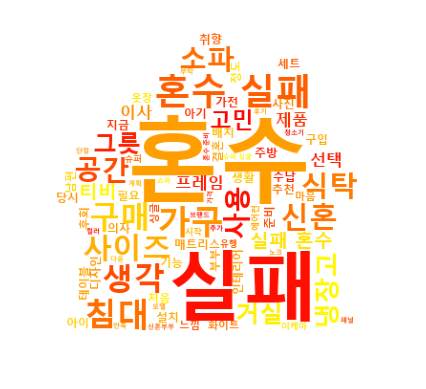

In [45]:
img = Image.open('./data/house1.jpg')
mask_img = np.array(img)

wc = WordCloud(
    font_path='C:/Windows/Fonts/malgunbd.ttf',
    background_color='white', mask=mask_img, colormap='autumn',
    width=2400,
    height=1600,
).generate_from_frequencies(dict(top_80))
plt.imshow(wc)
plt.axis('off')
plt.show()